In [117]:
import os
import numpy as np
from scipy.stats import ks_2samp, ttest_ind
from collections import Counter, defaultdict
import pandas as pd
from statsmodels.tsa.seasonal import STL
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False 

In [14]:
filepath = '../data/사내협력사 현황(철수사&거래 협력사)_ Data_송부_수정.xlsx'

In [15]:
df_raw_data_dict = pd.read_excel(filepath, sheet_name=None)
sheet_name_list = list(df_raw_data_dict.keys())

In [16]:
class Company:
    def __init__(self, company_id, catecory, subcategory, subsubcategory, start_date, end_date, label, data_duration):
        self.company_id = company_id
        self.catecory = catecory
        self.subcategory = subcategory
        self.subsubcategory = subsubcategory
        # self.start_date = pd.to_datetime(start_date).replace(day=1)
        self.start_date = pd.to_datetime(start_date).replace(day=1) if pd.to_datetime(start_date) > pd.to_datetime('2016-02-01') else pd.to_datetime('2016-02-01')
        self.end_date = pd.to_datetime('2024-10-01') if end_date == '-' else pd.to_datetime(end_date).replace(day=1)
        self.duration = (self.end_date.year - self.start_date.year) * 12 + (self.end_date.month - self.start_date.month) + 1
        self.condition = True if self.duration >= data_duration or self.duration < 0 else False
        self.label = True if label == '경영악화' else False
        self.data_dict = dict()

In [17]:
df_temp = df_raw_data_dict[sheet_name_list[0]]
column = list(df_temp.columns)[:8]
data_duration = 12
company_dict = dict()
for i, row in df_temp.iterrows():
    company_dict[row[column[0]]] = Company(row[column[0]], row[column[1]], row[column[2]], row[column[3]], row[column[4]], row[column[5]], row[column[7]], data_duration)

In [78]:
for sheet_name in sheet_name_list:
    if sheet_name in ['4대보험 체납', '종합평가']:
        print(sheet_name)
        continue
    else:
        if isinstance(df_temp.columns[-1], pd.Timestamp):
            new_cols = (list(df_temp.columns[:9]) + list(pd.to_datetime(df_temp.columns[9:]).map(lambda dt: dt.replace(day=1))))
        else:
            new_cols = (list(df_temp.columns[:9]) + list(pd.to_datetime(df_temp.columns[9:-1]).map(lambda dt: dt.replace(day=1))) + list(df_temp.columns[-1:]))
        df_temp.columns = new_cols
        for i, row in  df_raw_data_dict[sheet_name].iterrows():
            if company_dict[i + 1].condition:
                if not company_dict[i + 1].end_date in df_temp.columns:
                    print(company_dict[i + 1].end_date)
                    print(df_temp.columns[-5:])
                try:
                    col_index = df_temp.columns.get_loc(company_dict[i + 1].end_date) + 1
                    company_dict[i + 1].data_dict[sheet_name] = row[col_index - data_duration:col_index].fillna(0)
                except KeyError:
                    print(f'{sheet_name}: Key error')
                    break
            else:
                pass

4대보험 체납
종합평가


In [115]:
significant_pairs = []
unsignificant_pairs = []
sheet_ban = ['4대보험 체납', '종합평가', '임금체불']

for i in range(len(sheet_name_list)):
    for j in range(i + 1, len(sheet_name_list)):
        if sheet_name_list[i] in sheet_ban or sheet_name_list[j] in sheet_ban:
            continue
        sheet1 = sheet_name_list[i]
        sheet2 = sheet_name_list[j]

        correlations1 = []
        correlations2 = []
        
        error_count = 0
        for key, company in company_dict.items():
            if company.condition:
                x = company.data_dict[sheet1].to_numpy(dtype='float')
                y = company.data_dict[sheet2].to_numpy(dtype='float')
                if np.std(x) == 0 or np.std(y) == 0:
                    error_count += 1
                    continue
                corr = np.corrcoef(x, y)[0, 1]
                if company.label:
                    correlations1.append(np.round(corr, 3))
                else:
                    correlations2.append(np.round(corr, 3))
        
        if len(correlations1) >= 5 and len(correlations2) >= 5:
            ks_stat, ks_p = ks_2samp(correlations1, correlations2)
            t_stat, t_p = ttest_ind(correlations1, correlations2, equal_var=False)
            if ks_p < 0.05 or t_p < 0.05:
                significant_pairs.append({
                    'sheet1': sheet1,
                    'sheet2': sheet2,
                    'ks_p': round(ks_p, 4),
                    't_p': round(t_p, 4),
                    'n_경영악화': len(correlations1),
                    'n_정상': len(correlations2),
                    'error_count': error_count
                })
                
        else:
            unsignificant_pairs.append({
                'sheet1': sheet1,
                'sheet2': sheet2
            })

significant_df = pd.DataFrame(significant_pairs)
significant_df

,sheet1,sheet2,ks_p,t_p,n_경영악화,n_정상,error_count
0,기성매출(정상기성),총원,0.0000,0.0001,43,69,0
1,기성매출(정상기성),입사자,0.0446,0.0763,42,69,1
2,기성매출(정상기성),퇴사율,0.0065,0.0014,42,69,1
3,기성매출(정상기성),퇴사자,0.0198,0.0066,42,69,1
4,기성매출(정상기성),본공률(시급월급),0.0079,0.3725,42,63,7
5,기성매출(정상기성),"시급,월급제 인원",0.0000,0.0002,43,69,0
6,공수능률,환산능률,0.0045,0.2238,43,69,0
7,환산능률,총원,0.0746,0.0313,43,69,0
8,환산능률,퇴사율,0.0219,0.1616,42,69,1
9,환산능률,퇴사자,0.0446,0.2151,42,69,1


In [110]:
# 유의미한 쌍 수 계산
count_1 = Counter(significant_df['sheet1'])
count_2 = Counter(significant_df['sheet2'])
total_count = count_1 + count_2

# 어떤 시트와 유의미했는지 저장
related_sheets = defaultdict(set)
for _, row in significant_df.iterrows():
    s1, s2 = row['sheet1'], row['sheet2']
    related_sheets[s1].add(s2)
    related_sheets[s2].add(s1)

# 데이터프레임 구성
sheet_count_df = pd.DataFrame.from_dict(
    total_count, orient='index', columns=['유의미한 쌍 개수']
).sort_values(by='유의미한 쌍 개수', ascending=False)

# 오른쪽 열에 유의미한 시트 이름 추가
sheet_count_df['연관된 시트들'] = sheet_count_df.index.map(
    lambda sheet: ', '.join(sorted(related_sheets[sheet]))
)

sheet_count_df.index.name = 'sheet_name'
sheet_count_df.reset_index(inplace=True)
sheet_count_df

,sheet_name,유의미한 쌍 개수,연관된 시트들
0,"시급,월급제 인원",8,"4대보험 가입자, 기성매출(정상기성), 본공률(시급월급), 입사자, 총원, 퇴사율,..."
1,퇴사율,7,"기성매출(정상기성), 본공률(시급월급), 시급,월급제 인원, 입사율, 입사자, 총원..."
2,기성매출(정상기성),6,"본공률(시급월급), 시급,월급제 인원, 입사자, 총원, 퇴사율, 퇴사자"
3,환산능률,6,"공수능률, 본공률(시급월급), 시급,월급제 인원, 총원, 퇴사율, 퇴사자"
4,입사자,6,"기성매출(정상기성), 본공률(시급월급), 시급,월급제 인원, 입사율, 퇴사율, 퇴사자"
5,퇴사자,6,"기성매출(정상기성), 시급,월급제 인원, 입사율, 입사자, 총원, 환산능률"
6,총원,5,"기성매출(정상기성), 시급,월급제 인원, 퇴사율, 퇴사자, 환산능률"
7,본공률(시급월급),5,"기성매출(정상기성), 시급,월급제 인원, 입사자, 퇴사율, 환산능률"
8,입사율,3,"입사자, 퇴사율, 퇴사자"
9,4대보험 가입자,2,"본공률(4대보험), 시급,월급제 인원"


In [124]:
significant_features = []
unsignificant_features = []
sheet_ban = ['4대보험 체납', '종합평가', '임금체불']

# 각 시트를 순회합니다.
for sheet in sheet_name_list:
    # 금지된 시트는 건너뜁니다.
    if sheet in sheet_ban:
        continue

    group_true = []   # label == True인 경우의 잔차 값들을 저장합니다.
    group_false = []  # label == False인 경우의 잔차 값들을 저장합니다.
    error_count = 0

    # 각 회사의 데이터를 처리합니다.
    for key, company in company_dict.items():
        if company.condition:
            try:
                # 각 회사의 시계열 데이터 (길이 12)를 float 형식의 numpy array로 가져옵니다.
                data_arr = company.data_dict[sheet].to_numpy(dtype='float')
            except Exception as e:
                error_count += 1
                continue
            
            # 데이터의 표준편차가 0이면 시계열 분해가 불가능하므로 건너뜁니다.
            if np.std(data_arr) == 0:
                error_count += 1
                continue
            
            # STL 분해를 수행합니다.
            # period=12는 12개월 또는 12주기 데이터를 가정한 설정입니다.
            try:
                stl = STL(data_arr, period=12, robust=True)
                res = stl.fit().resid  # 잔차(residual) 성분을 추출합니다.
            except Exception as e:
                error_count += 1
                continue
                
            # (예시: 회사별 평균 잔차를 계산하여 그룹에 추가하는 경우)
            if company.label:
                group_true.append(np.round(np.mean(res), 3))
            else:
                group_false.append(np.round(np.mean(res), 3))


    # 충분한 데이터(각 그룹 최소 5개 이상)가 있는 경우에만 통계적 검정을 진행합니다.
    if len(group_true) >= 5 and len(group_false) >= 5:
        ks_stat, ks_p = ks_2samp(group_true, group_false)
        t_stat, t_p = ttest_ind(group_true, group_false, equal_var=False)
        
        # 두 검정 중 하나라도 p-value가 0.05 미만이면 두 그룹 간 분포에 유의한 차이가 있다고 판단합니다.
        if ks_p < 0.05 or t_p < 0.05:
            significant_features.append({
                'feature': sheet,
                'ks_p': round(ks_p, 4),
                't_p': round(t_p, 4),
                'n_경영악화': len(group_true),
                'n_정상': len(group_false),
                'error_count': error_count
            })
    else:
        unsignificant_features.append({'feature': sheet})

# 결과를 DataFrame으로 정리합니다.
significant_df = pd.DataFrame(significant_features)
print(significant_df)


Empty DataFrame
Columns: []
Index: []


In [123]:
len(sheet_name_list)

17

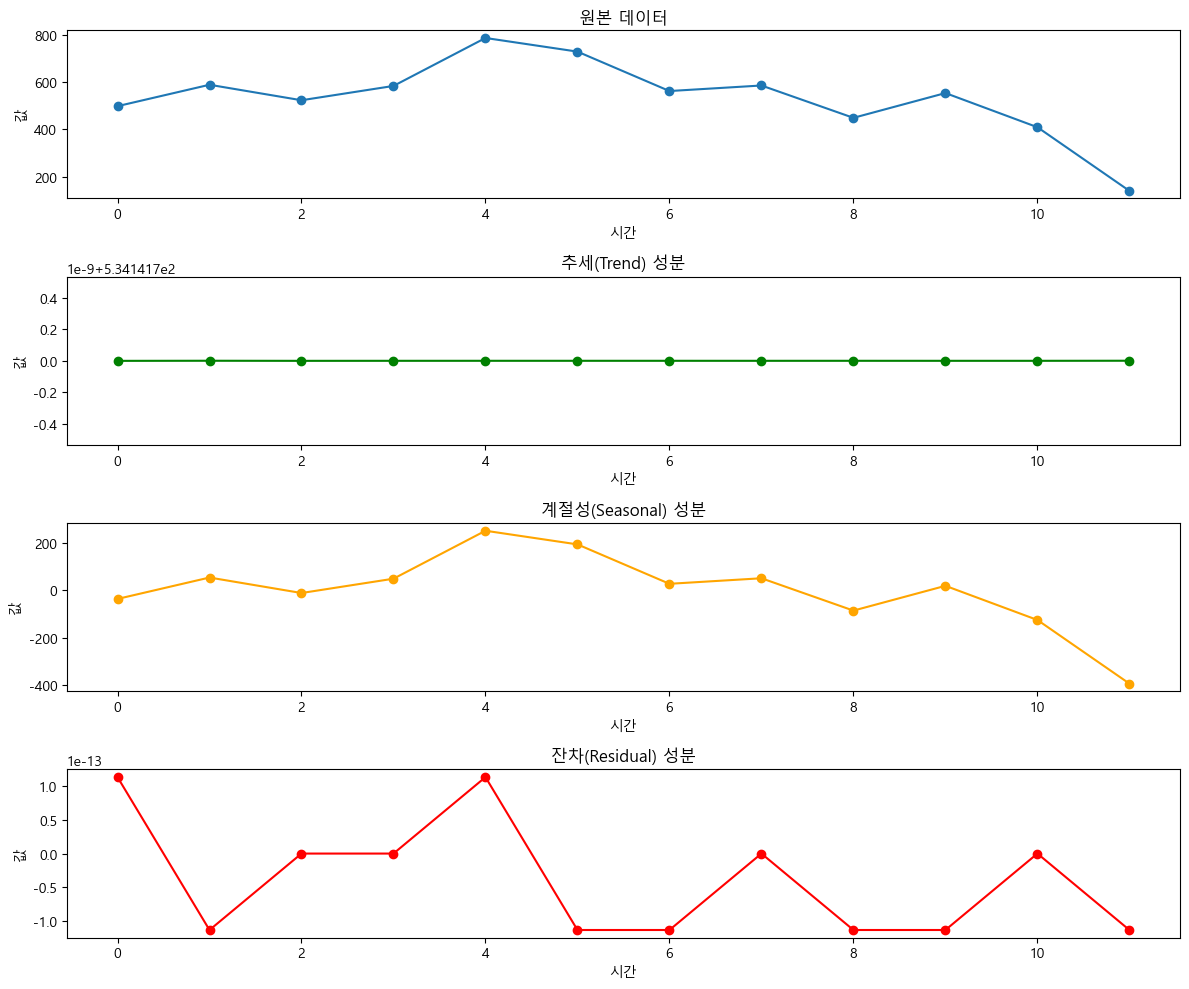

In [121]:
# 예시: 조건을 만족하는 첫 번째 회사를 선택합니다.
# company_dict와 sheet_name_list는 이미 정의되어 있다고 가정합니다.
for key, company in company_dict.items():
    if company.condition:
        try:
            # sheet_name_list의 첫 번째 시트의 데이터를 numpy array로 변환합니다.
            data_arr = company.data_dict[sheet_name_list[0]].to_numpy(dtype='float')
        except Exception as e:
            continue
        
        # 데이터의 표준편차가 0이면 의미있는 분해가 어려우므로 건너뜁니다.
        if np.std(data_arr) == 0:
            continue
        
        # STL 분해 수행. period=12 는 데이터가 12 기간(예: 월별 등)임을 가정합니다.
        stl = STL(data_arr, period=12, robust=True)
        result = stl.fit()
        break  # 첫 번째 조건 충족 회사만 예제로 사용합니다.

# 결과가 존재하는 경우, 원본 시계열과 분해된 성분들을 플롯합니다.
plt.figure(figsize=(12, 10))

plt.subplot(4, 1, 1)
plt.plot(data_arr, marker='o')
plt.title('원본 데이터')
plt.xlabel('시간')
plt.ylabel('값')

plt.subplot(4, 1, 2)
plt.plot(result.trend, marker='o', color='green')
plt.title('추세(Trend) 성분')
plt.xlabel('시간')
plt.ylabel('값')

plt.subplot(4, 1, 3)
plt.plot(result.seasonal, marker='o', color='orange')
plt.title('계절성(Seasonal) 성분')
plt.xlabel('시간')
plt.ylabel('값')

plt.subplot(4, 1, 4)
plt.plot(result.resid, marker='o', color='red')
plt.title('잔차(Residual) 성분')
plt.xlabel('시간')
plt.ylabel('값')

plt.tight_layout()
plt.show()

In [122]:
data_arr, result.trend, result.seasonal, result.resid

(array([498.3735, 588.6475, 523.3157, 583.681 , 786.0001, 728.4261,
        562.1748, 585.5558, 449.1202, 553.6566, 409.6134, 141.1357]),
 array([534.1417, 534.1417, 534.1417, 534.1417, 534.1417, 534.1417,
        534.1417, 534.1417, 534.1417, 534.1417, 534.1417, 534.1417]),
 array([ -35.7682,   54.5058,  -10.826 ,   49.5393,  251.8584,  194.2844,
          28.0331,   51.4141,  -85.0215,   19.5149, -124.5283, -393.006 ]),
 array([ 1.13686838e-13, -1.13686838e-13,  0.00000000e+00,  0.00000000e+00,
         1.13686838e-13, -1.13686838e-13, -1.13686838e-13,  0.00000000e+00,
        -1.13686838e-13, -1.13686838e-13,  0.00000000e+00, -1.13686838e-13]))

In [111]:
ks_stat, ks_p = ks_2samp(correlations1, correlations2)

# t-검정
t_stat, t_p = ttest_ind(correlations1, correlations2, equal_var=False)

print(f"[KS 검정] 통계량: {ks_stat:.4f}, p-value: {ks_p:.4f}")
print(f"[t-검정] 통계량: {t_stat:.4f}, p-value: {t_p:.4f}")

ValueError: Data passed to ks_2samp must not be empty

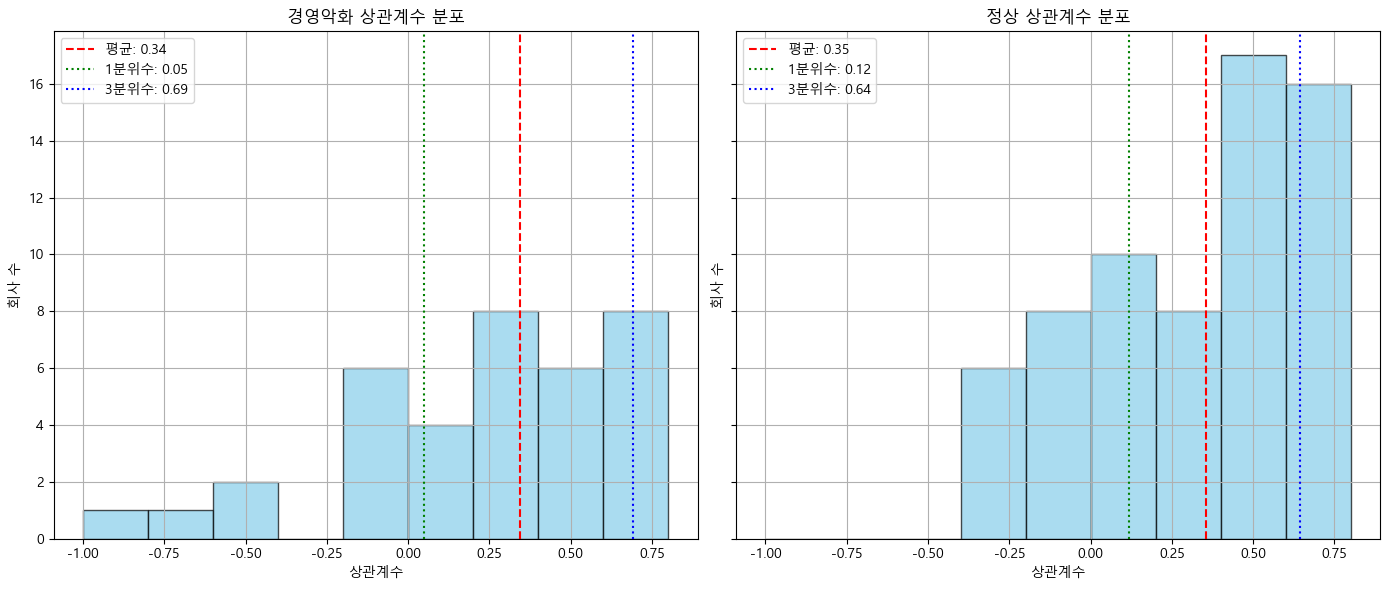

In [58]:
# bins 설정
bins = np.arange(-1.0, 1.0, 0.2)

# 시각화 시작
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# 데이터와 라벨 묶기
datasets = [(correlations1, '경영악화'), (correlations2, '정상')]

for ax, (data, label) in zip(axes, datasets):
    # 히스토그램
    ax.hist(data, bins=bins, alpha=0.7, edgecolor='black', color='skyblue')
    ax.set_title(f'{label} 상관계수 분포')
    ax.set_xlabel('상관계수')
    ax.set_ylabel('회사 수')
    ax.grid(True)

    # 통계 지표
    mean = np.mean(data)
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)

    # 수직선 표시
    ax.axvline(mean, color='red', linestyle='--', label=f'평균: {mean:.2f}')
    ax.axvline(q1, color='green', linestyle=':', label=f'1분위수: {q1:.2f}')
    ax.axvline(q3, color='blue', linestyle=':', label=f'3분위수: {q3:.2f}')
    ax.legend()

plt.tight_layout()
plt.show()


In [50]:
correlations1

[0.662,
 -0.159,
 0.192,
 0.265,
 0.365,
 0.971,
 0.661,
 0.491,
 -0.435,
 0.345,
 0.832,
 -0.136,
 -0.849,
 -0.102,
 0.796,
 -0.634,
 0.883,
 0.781,
 -0.482,
 0.599,
 0.362,
 0.749,
 -0.125,
 -0.055,
 0.092,
 0.008,
 0.234,
 0.265,
 0.835,
 0.862,
 0.48,
 -0.061,
 0.632,
 0.633,
 0.918,
 0.31,
 0.445,
 0.576,
 0.159,
 0.962,
 0.401,
 0.723,
 0.276]

In [19]:
## 라벨 수 및 운영 기간 분석
temp = []
count = 0
label_True = 0 
label_True_count = 0 
label_False = 0
label_False_count = 0
for key, value in company_dict.items():
    if value.label:
        label_True = label_True + 1
    else:
        label_False = label_False + 1
    if not value.condition:
        count += 1
    else:
        if value.label:
            label_True_count = label_True_count + 1
        else:
            label_False_count = label_False_count + 1
        temp.append(value.duration)
print(np.mean(temp))
print(np.std(temp))
print(np.quantile(temp, 0.25))
print(np.quantile(temp, 0.5))
print(np.quantile(temp, 0.75))
print(np.min(temp))
print(np.max(temp))

print(len(company_dict), label_True, label_False)
print(count, label_True_count, label_False_count)

64.80357142857143
29.641259638537356
36.0
69.0
91.25
13
105
127 44 83
15 43 69


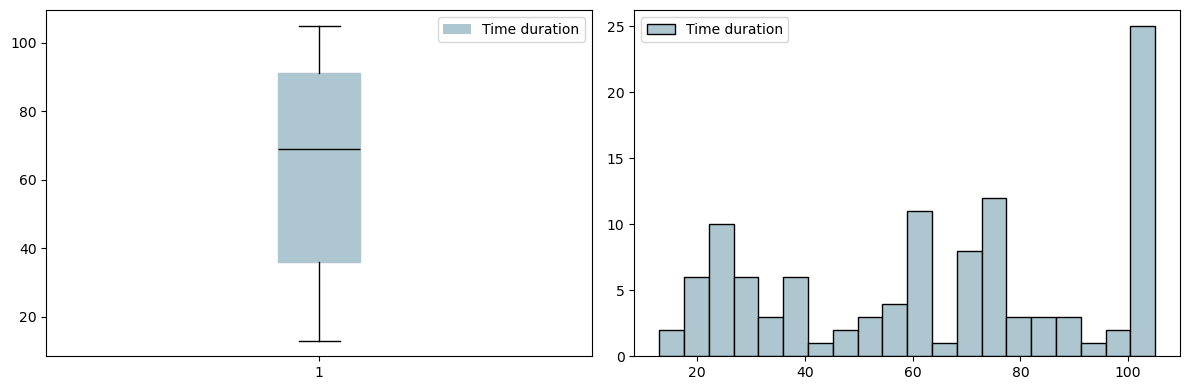

In [20]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 박스 플롯
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.boxplot(temp, vert=True, patch_artist=True, boxprops=dict(facecolor='#aec6cf', color='#aec6cf'),
    medianprops=dict(color='black'))

box_patch = mpatches.Patch(facecolor='#aec6cf', label='Time duration')
plt.legend(handles=[box_patch])

# 히스토그램
plt.subplot(1, 2, 2)
plt.hist(temp, bins=20, edgecolor='black', color='#aec6cf', label='Time duration')
plt.legend()

plt.tight_layout()
plt.savefig('high_resolution_plot.png', dpi=1000, bbox_inches='tight')
plt.show()

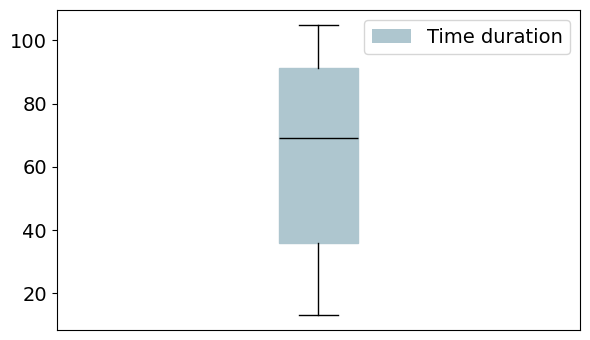

In [21]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.figure(figsize=(6, 3.5))  # 하나의 플롯만 있으므로 figsize를 조정합니다.

plt.boxplot(temp, vert=True, patch_artist=True, 
            boxprops=dict(facecolor='#aec6cf', color='#aec6cf'),
            medianprops=dict(color='black'))

# 범례 추가
box_patch = mpatches.Patch(facecolor='#aec6cf', label='Time duration')
plt.legend(handles=[box_patch], fontsize=14)

# x축 숫자 제거
plt.xticks([])
plt.yticks(fontsize=14)

plt.tight_layout()
plt.savefig('high_resolution_plot2.png', dpi=1000, bbox_inches='tight')
plt.show()

In [23]:
# 퇴사율에 대해서만 분석

temp1 = []
temp2 = []
for key, value in company_dict.items():
    if value.condition:
        if value.label:
            temp1.append(list(value.data_dict['퇴사율']))
        else:
            temp2.append(list(value.data_dict['퇴사율']))
    else:
        continue
dates = range(12)
df_temp1 = pd.DataFrame(temp1, columns=dates)
df_temp1 = df_temp1.apply(pd.to_numeric, errors='coerce')
df_temp1 = df_temp1.dropna(how='all').fillna(0)
df_temp1

,0,1,2,3,4,5,6,7,8,9,10,11
0,0.026906,0.027778,0.056277,0.008097,0.029412,0.039301,0.026786,0.039604,0.032432,0.022346,0.125714,0.000000
1,0.037879,0.055249,0.026393,0.031546,0.031034,0.037736,0.008368,0.020979,0.174603,0.181818,0.066667,0.000000
2,0.009804,0.020202,0.016129,0.022388,0.032787,0.039062,0.013889,0.098039,0.008197,0.025424,0.018182,0.027523
3,0.044444,0.060606,0.043796,0.081967,0.192982,0.032847,0.040956,0.101083,0.077982,0.006369,0.000000,0.000000
4,0.000000,0.075949,0.025424,0.049020,0.021978,0.000000,0.011905,0.166667,0.020202,0.026549,0.009434,0.009091
5,0.037736,0.065359,0.080000,0.013423,0.051095,1.054348,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,0.006536,0.000000,0.013158,0.078947,0.051095,0.022388,0.031250,0.086331,0.043478,0.005747,0.026882,0.890476
7,0.022727,0.044444,0.056604,0.009804,0.042373,0.040000,0.041322,0.066667,0.036765,0.028777,0.021898,0.079710
8,0.000000,0.000000,0.053571,0.059701,0.072464,0.030928,0.112150,0.009317,0.094872,0.165730,0.121519,0.922078
9,0.010870,0.109890,0.459770,0.038462,0.165563,0.224490,0.176829,0.126866,0.032520,0.224000,0.044776,0.696296


In [24]:
df_temp2 = pd.DataFrame(temp2, columns=dates)
df_temp2 = df_temp2.apply(pd.to_numeric, errors='coerce')
df_temp2 = df_temp2.dropna(how='all').fillna(0)
df_temp2

,0,1,2,3,4,5,6,7,8,9,10,11
0,0.081897,0.111554,0.154472,0.081197,0.163793,0.245192,0.106667,0.189300,0.150794,0.280899,0.110599,0.147321
1,0.035000,0.036082,0.047120,0.030769,0.055000,0.050251,0.041885,0.059140,0.127778,0.025157,0.043210,0.006452
2,0.039604,0.000000,0.020000,0.000000,0.009434,0.026549,0.008403,0.032520,0.037879,0.022901,0.007692,0.038462
3,0.019231,0.000000,0.044586,0.029412,0.038251,0.048649,0.081340,0.097436,0.101695,0.043956,0.060109,0.083333
4,0.077465,0.103704,0.061069,0.125984,0.066667,0.035714,0.024793,0.107692,0.058333,0.066667,0.068376,0.043860
...,...,...,...,...,...,...,...,...,...,...,...,...
64,0.056180,0.080460,0.097561,0.126582,0.049383,0.036145,0.098901,0.082353,0.069767,0.083333,0.086207,0.078261
65,0.097015,0.067669,0.028777,0.055944,0.064286,0.007353,0.036765,0.036765,0.022727,0.007576,0.007519,0.029630
66,0.163717,0.038095,0.136170,0.072961,0.028708,0.046948,0.026667,0.029661,0.106838,0.073394,0.056738,0.056140
67,0.164062,0.114754,0.096070,0.093333,0.103004,0.090129,0.124498,0.111570,0.198444,0.093220,0.066667,0.065502


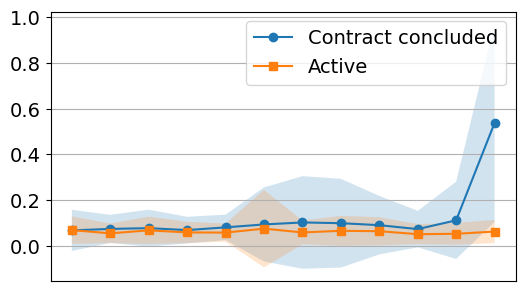

In [26]:
# 평균과 표준편차 계산
mean1 = df_temp1.mean(axis=0)
std1 = df_temp1.std(axis=0)
mean2 = df_temp2.mean(axis=0)
std2 = df_temp2.std(axis=0)

# 시계열 x축 값: DataFrame의 컬럼명이 날짜나 숫자라면 그대로 사용, 아니라면 단순 숫자 1~6
time_points = df_temp1.columns if np.issubdtype(df_temp1.columns.dtype, np.number) or isinstance(df_temp1.columns[0], str) else range(1,13)

plt.figure(figsize=(6,3.5))
plt.plot(time_points, mean1, marker='o', label='Contract concluded')
plt.fill_between(time_points, mean1 - std1, mean1 + std1, alpha=0.2)
plt.plot(time_points, mean2, marker='s', label='Active')
plt.fill_between(time_points, mean2 - std2, mean2 + std2, alpha=0.2)
plt.legend(fontsize=14)
plt.yticks(fontsize=14)
plt.xticks([])
plt.grid(True)
plt.savefig('data_plot.png', dpi=1000, bbox_inches='tight')
plt.show()